# HVSR analysis with hvsrpy

Processing functions live in [`utils/hvsr_tools.py`](../../utils/hvsr_tools.py). This notebook only sets inputs and parameters and calls them.

Pipeline: read N/E/Z → optional filter → STA/LTA anti-trigger and window placement → detrend → cosine taper → FFT → horizontal combination → smoothing → H/V → statistics.

In [9]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

PROJECT_ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p / "utils").is_dir())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.hvsr_tools import (
    HVSRParams, load_record, run_hvsr, read_reference_curve, compare_curves,
    parameter_sweep, plot_hvsr, plot_window_selection, plot_comparison, save_outputs,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Inputs and parameters

In [10]:
DATA_DIR = PROJECT_ROOT / "HVMATLAB"
INPUT_FILES = {
    "N": DATA_DIR / "00P2-2_WA.WAU40..HHN.D.2020.281.sac",
    "E": DATA_DIR / "00P2-2_WA.WAU40..HHE.D.2020.281.sac",
    "Z": DATA_DIR / "00P2-2_WA.WAU40..HHZ.D.2020.281.sac",
}
OUTPUT_DIR = PROJECT_ROOT / "main" / "02_analysis_hv" / "outputs_hvsrpy"
OUTPUT_PREFIX = "00P2-2"
REFERENCE_CURVE = None  # optional path to an H/V curve (.hv / .txt / .csv) for comparison

params = HVSRParams(
    # time windows
    window_length_s=32.0,
    overlap_pct=0.0,
    window_selection="continuous",   # "continuous" | "grid"
    # anti-trigger
    anti_trigger=True,
    sta_lta_mode="continuous",       # "continuous" | "per_window" (grid only)
    sta_s=2.0,
    lta_s=25.0,
    sta_lta_min=0.2,
    sta_lta_max=2.0,
    sta_lta_components=("N", "E", "Z"),
    sta_lta_amplitude="abs",         # "abs" | "square"
    sta_lta_on_filtered=False,
    clip_threshold_pct=99.0,         # None to disable
    # pre-processing
    filter_corners_hz=(None, None),  # e.g. (0.2, None) high-pass
    filter_order=5,
    detrend="linear",                # "linear" | "constant" | "none"
    # spectra
    taper=True,
    taper_pct=2.0,
    taper_pct_per_side=True,
    fft_zero_padding=True,
    smoothing="konno_and_ohmachi",
    smoothing_bandwidth=40.0,
    smoothing_scale="linear",       # "linear" | "log" (smooth log-amplitude spectra)
    horizontal_combination="squared_average",  # "geometric_mean", "total_horizontal_energy", ...
    # output frequencies
    fmin=0.5,
    fmax=30.0,
    frequency_spacing="log",
    n_frequencies=1000,
    # peak picking and statistics
    peak_range_hz=None,              # None -> (fmin, fmax)
    peak_method="max",               # "max" | "find_peaks"
    distribution="lognormal",
    frequency_domain_rejection=False,
)

In [11]:
record = load_record(INPUT_FILES)
{k: record.meta[k] for k in ("station", "starttime", "sampling_rate_hz", "duration_s")}

{'station': '00P2-2',
 'starttime': '2020-10-07T08:18:39.000000Z',
 'sampling_rate_hz': 100.0,
 'duration_s': 28160.99}

## H/V

In [12]:
result = run_hvsr(record, params)
summary = result.summary(show=True)

windows 675/880  |  f0 = 10.08 Hz, A0 = 5.22  |  f0 windows = 9.441 Hz  [2.3 s]
n_grid_windows            : 880
n_windows_time_selection  : 675
n_windows                 : 675
valid_fraction            : 0.9712
f0_mean_curve_hz          : 10.08
A0_mean_curve             : 5.22
f0_windows_hz             : 9.441
f0_windows_std            : 0.2767
f0_windows_low_hz         : 7.159
f0_windows_high_hz        : 12.45
A0_windows                : 5.952
fdr_iterations            : None
runtime_s                 : 2.28


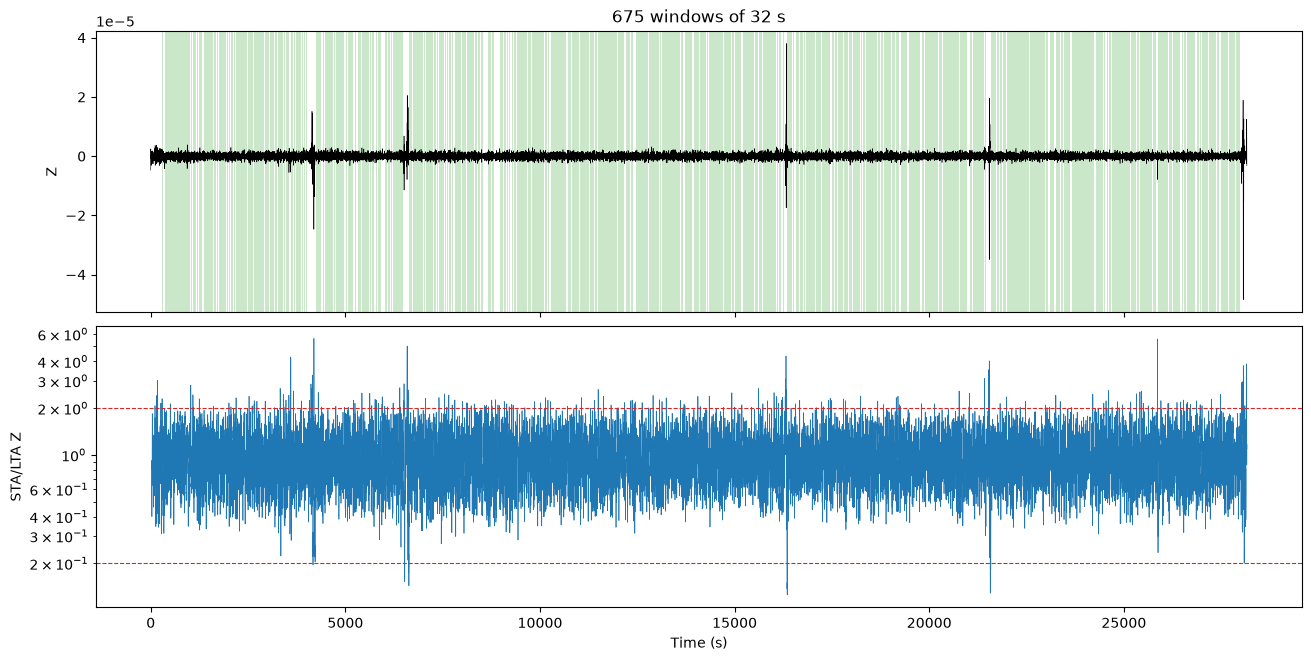

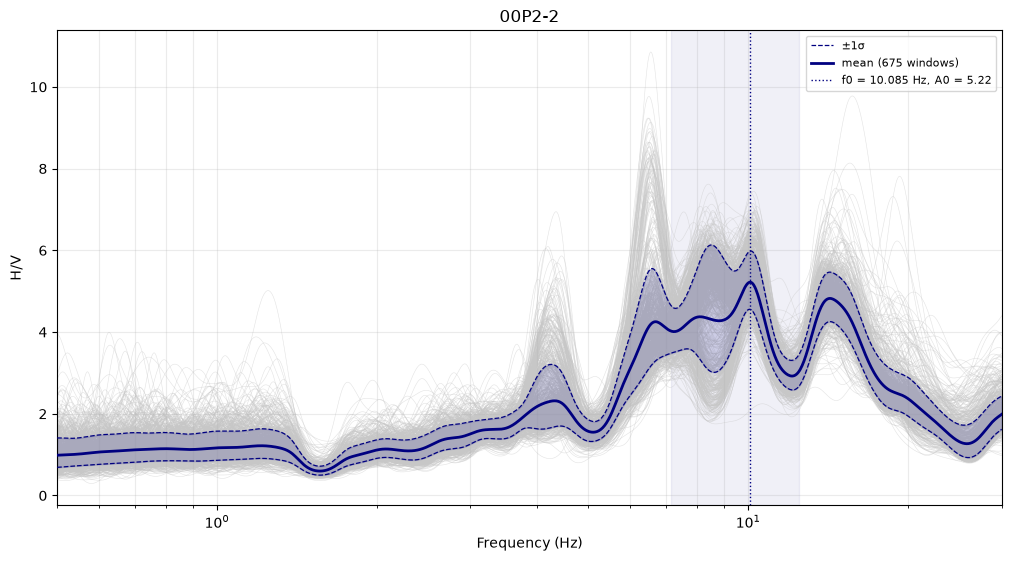

In [13]:
plot_window_selection(record, result, component="Z")
plt.show()

plot_hvsr(result, title=record.meta["station"])
plt.show()

## Comparison with a reference curve (optional)

In [14]:
reference = read_reference_curve(REFERENCE_CURVE) if REFERENCE_CURVE else None
if reference is not None:
    display(compare_curves(result, reference))
    plot_comparison(result, reference, title=f"{record.meta['station']} vs {reference.label}")
    plt.show()

## Parameter sweep (optional)

Runs every combination in `SWEEP_GRID` starting from `params`. With a reference curve the table is sorted by misfit (`rms_log10`).

In [15]:
SWEEP_GRID = {
    "smoothing_scale": ["linear", "log"],
    "smoothing_bandwidth": [20, 30, 40],
    "fft_zero_padding": [True, False],
    "anti_trigger": [True, False],
}
RUN_SWEEP = False

if RUN_SWEEP:
    sweep = parameter_sweep(record, params, SWEEP_GRID, reference=reference)
    display(sweep)
    # params = params.update(**sweep.loc[0, list(SWEEP_GRID)].to_dict())

## SESAME criteria and export

In [16]:
sesame = result.sesame(verbose=1)

paths = save_outputs(result, OUTPUT_DIR, prefix=OUTPUT_PREFIX, extra={"sesame": sesame})
ax = plot_hvsr(result, reference=reference, title=record.meta["station"])
paths["figure"] = OUTPUT_DIR / f"{OUTPUT_PREFIX}_hv.png"
ax.figure.savefig(paths["figure"], dpi=180)
plt.close(ax.figure)
paths

Considering only frequencies between 0.500 and 30.000 Hz.
Assessing SESAME (2004) reliability criteria ... 
  Criteria i): Pass
  Criteria ii): Pass
  Criteria iii): Pass
  The chosen peak PASSES the peak reliability criteria, with 3 of 3.
Assessing SESAME (2004) clarity criteria ... 
Considering only frequencies between 0.500 and 30.000 Hz.
  Criteria i): Pass
  Criteria ii): Pass
  Criteria iii): Pass
  Criteria iv): Fail
  Criteria v): Fail
  Criteria vi): Pass
  The chosen peak FAILS the peak clarity criteria, with 4 of 6.


{'curve': PosixPath('/home/orincon/ciudad-perdida-hvsr/main/02_analysis_hv/outputs_hvsrpy/00P2-2.hv'),
 'windows': PosixPath('/home/orincon/ciudad-perdida-hvsr/main/02_analysis_hv/outputs_hvsrpy/00P2-2_windows.csv'),
 'summary': PosixPath('/home/orincon/ciudad-perdida-hvsr/main/02_analysis_hv/outputs_hvsrpy/00P2-2_summary.json'),
 'figure': PosixPath('/home/orincon/ciudad-perdida-hvsr/main/02_analysis_hv/outputs_hvsrpy/00P2-2_hv.png')}